In [81]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [82]:
credit_card_data = pd.read_csv('credit_card_fraud_10k.csv')

In [83]:
credit_card_data.head()

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.47,22,Electronics,0,0,66,3,40,0
1,2,541.82,3,Travel,1,0,87,1,64,0
2,3,237.01,17,Grocery,0,0,49,1,61,0
3,4,164.33,4,Grocery,0,1,72,3,34,0
4,5,30.53,15,Food,0,0,79,0,44,0


In [84]:
credit_card_data.tail()

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
9995,9996,350.91,22,Food,0,0,99,4,37,0
9996,9997,410.04,5,Clothing,0,0,70,3,25,0
9997,9998,527.75,21,Electronics,0,0,44,2,45,0
9998,9999,91.20,2,Electronics,0,0,38,0,37,0
9999,10000,44.06,2,Clothing,0,0,38,0,66,0


In [85]:
credit_card_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   transaction_id       10000 non-null  int64  
 1   amount               10000 non-null  float64
 2   transaction_hour     10000 non-null  int64  
 3   merchant_category    10000 non-null  str    
 4   foreign_transaction  10000 non-null  int64  
 5   location_mismatch    10000 non-null  int64  
 6   device_trust_score   10000 non-null  int64  
 7   velocity_last_24h    10000 non-null  int64  
 8   cardholder_age       10000 non-null  int64  
 9   is_fraud             10000 non-null  int64  
dtypes: float64(1), int64(8), str(1)
memory usage: 781.4 KB


In [86]:
credit_card_data.isnull().sum()

transaction_id         0
amount                 0
transaction_hour       0
merchant_category      0
foreign_transaction    0
location_mismatch      0
device_trust_score     0
velocity_last_24h      0
cardholder_age         0
is_fraud               0
dtype: int64

In [87]:
credit_card_data['is_fraud'].value_counts()

is_fraud
0    9849
1     151
Name: count, dtype: int64

In [88]:
legit = credit_card_data[credit_card_data.is_fraud==0]
fraud = credit_card_data[credit_card_data.is_fraud==1]

In [89]:
print(legit.shape)
print(fraud.shape)

(9849, 10)
(151, 10)


In [ ]:
legit['amount'].describe()

count    9849.000000
mean      175.333015
std       173.986837
min         0.000000
25%        50.990000
50%       122.110000
75%       241.650000
max      1471.040000
Name: amount, dtype: float64

In [ ]:
fraud['amount'].describe()

count     151.000000
mean      216.182980
std       248.120467
min         0.110000
25%        41.530000
50%       118.940000
75%       341.695000
max      1185.070000
Name: amount, dtype: float64

In [ ]:
credit_card_data.groupby('is_fraud').mean(numeric_only=True)

,transaction_id,amount,transaction_hour,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age
is_fraud,,,,,,,,
0,5004.129861,175.333015,11.712154,0.090974,0.079704,62.165804,1.990557,43.469794
1,4763.741722,216.182980,3.841060,0.543046,0.476821,37.867550,3.205298,43.397351


In [ ]:
print(credit_card_data['is_fraud'].value_counts())

is_fraud
0    9849
1     151
Name: count, dtype: int64


In [ ]:
legit_sample = legit.sample(n=492)

In [ ]:
new_dataset= pd.concat([legit_sample,fraud],axis=0)

In [ ]:
new_dataset.head()

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
6160,6161,30.27,0,Food,0,0,83,4,31,0
9358,9359,346.77,8,Food,0,1,59,2,26,0
1138,1139,117.91,20,Grocery,0,1,69,5,36,0
6178,6179,39.65,13,Food,0,0,44,1,58,0
5053,5054,15.98,7,Food,0,0,63,2,37,0


In [ ]:
new_dataset.tail()

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
9526,9527,398.66,3,Grocery,0,0,30,5,61,1
9553,9554,182.65,2,Electronics,1,1,31,2,28,1
9587,9588,93.93,1,Travel,0,1,27,3,69,1
9779,9780,172.00,2,Grocery,0,1,56,5,24,1
9973,9974,11.22,1,Grocery,0,1,25,4,32,1


In [ ]:
new_dataset['is_fraud'].value_counts()

is_fraud
0    492
1    151
Name: count, dtype: int64

In [ ]:
new_dataset.groupby('is_fraud').mean(numeric_only=True)

,transaction_id,amount,transaction_hour,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age
is_fraud,,,,,,,,
0,5023.837398,178.896585,11.441057,0.075203,0.085366,61.136179,2.026423,43.861789
1,4763.741722,216.182980,3.841060,0.543046,0.476821,37.867550,3.205298,43.397351


In [ ]:
x = new_dataset.drop(columns='is_fraud')
y = new_dataset['is_fraud']

In [ ]:
print(x)
print(y)

      transaction_id  amount  transaction_hour merchant_category  \
6160            6161   30.27                 0              Food   
9358            9359  346.77                 8              Food   
1138            1139  117.91                20           Grocery   
6178            6179   39.65                13              Food   
5053            5054   15.98                 7              Food   
...              ...     ...               ...               ...   
9526            9527  398.66                 3           Grocery   
9553            9554  182.65                 2       Electronics   
9587            9588   93.93                 1            Travel   
9779            9780  172.00                 2           Grocery   
9973            9974   11.22                 1           Grocery   

      foreign_transaction  location_mismatch  device_trust_score  \
6160                    0                  0                  83   
9358                    0                  1   

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

x['merchant_category'] = le.fit_transform(x['merchant_category'])

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,stratify=y,random_state=2)

print(x.shape,x_train.shape,x_test.shape)

(643, 9) (514, 9) (129, 9)


In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(x_train, y_train)

/opt/homebrew/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [ ]:
x_train_prediction = model.predict(x_train)
training_data_accuracy = accuracy_score(x_train_prediction,y_train)

In [ ]:
y_pred = model.predict(x_test)

print("Unique predictions:", set(y_pred))

Unique predictions: {np.int64(0), np.int64(1)}


In [ ]:
if y_pred[0] == 0:
    result = "✅ Legitimate Transaction"
else:
    result = "🚨 Fraudulent Transaction"

In [ ]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(x_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9767441860465116


In [ ]:
x_test_prediction = model.predict(x_test)
test_data_accuracy = accuracy_score(x_test_prediction,y_test)

In [ ]:
print("Accuracy on Test data:",test_data_accuracy)

Accuracy on Test data: 0.9767441860465116


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

print("Training Report:\n")
print(classification_report(y_train, x_train_prediction))

print("Test Report:\n")
print(classification_report(y_test, x_test_prediction))

Training Report:

              precision    recall  f1-score   support

           0       0.97      0.97      0.97       393
           1       0.92      0.92      0.92       121

    accuracy                           0.96       514
   macro avg       0.95      0.95      0.95       514
weighted avg       0.96      0.96      0.96       514

Test Report:

              precision    recall  f1-score   support

           0       0.98      0.99      0.98        99
           1       0.97      0.93      0.95        30

    accuracy                           0.98       129
   macro avg       0.97      0.96      0.97       129
weighted avg       0.98      0.98      0.98       129



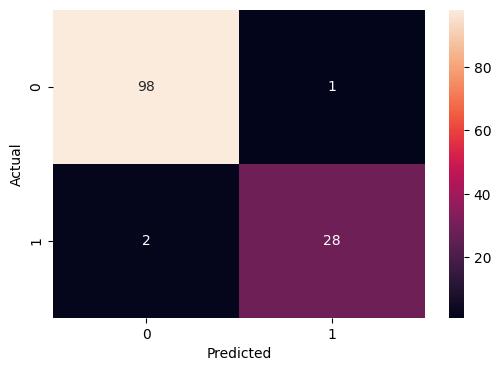

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, x_test_prediction)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [ ]:
import joblib

cols = joblib.load("feature_columns.pkl")

print("Number of features:", len(cols))
print(cols)

['credit_card_fraud_model.pkl']

In [ ]:
model = joblib.load("credit_card_fraud_model.pkl")